In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import time
import joblib
import os
import sys

In [88]:
data = pd.read_csv("../data/train_transaction.csv")
data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [89]:
data['hour'] = (data['TransactionDT'] // 3600) % 24
data['day'] = (data['TransactionDT'] // (3600 * 24)) % 7

Y = data['isFraud']

data = data.drop(columns=['TransactionID', 'isFraud', 'TransactionDT'])

null = data.isnull().sum()
good_cols = null[null < 120000].index.tolist()
X = data[good_cols]
X = X.copy()

print(f"Features: {len(good_cols)}")
print(f"X shape: {X.shape}")
print(f"hour in features: {'hour' in good_cols}")
print(f"day in features: {'day' in good_cols}")

Features: 181
X shape: (590540, 181)
hour in features: True
day in features: True


In [90]:
print(X.select_dtypes(include='object').columns.tolist())
print(f"Categorical columns: {len(X.select_dtypes(include='object').columns)}")

['ProductCD', 'card4', 'card6', 'P_emaildomain']
Categorical columns: 4


In [91]:
print(X.isnull().sum().sum())

5667093


In [92]:
numeric_cols = X.select_dtypes(exclude='object').columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].fillna('missing')

print(X.isnull().sum().sum())

0


In [93]:
X = pd.get_dummies(X, columns=cat_cols)
print(X.shape)

(590540, 252)


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.17, random_state=42, stratify=y)

In [95]:
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Fraud in train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Fraud in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Training set: (490148, 252)
Test set: (100392, 252)
Fraud in train: 17150 (3.5%)
Fraud in test: 3513 (3.5%)


In [96]:
start = time.time()
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print(f"Training took: {time.time() - start:.1f} seconds")

Training took: 105.2 seconds


In [97]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99     96879
       Fraud       0.93      0.43      0.59      3513

    accuracy                           0.98    100392
   macro avg       0.95      0.71      0.79    100392
weighted avg       0.98      0.98      0.97    100392



In [98]:
os.makedirs('models', exist_ok=True)
joblib.dump(model, '../models/random_forest.pkl')
print("Model saved")

# verify it loads correctly
loaded_model = joblib.load('../models/random_forest.pkl')
y_pred_verify = loaded_model.predict(X_test[:5])
print(f"Verification predictions: {y_pred_verify}")

Model saved
Verification predictions: [0 1 0 0 0]


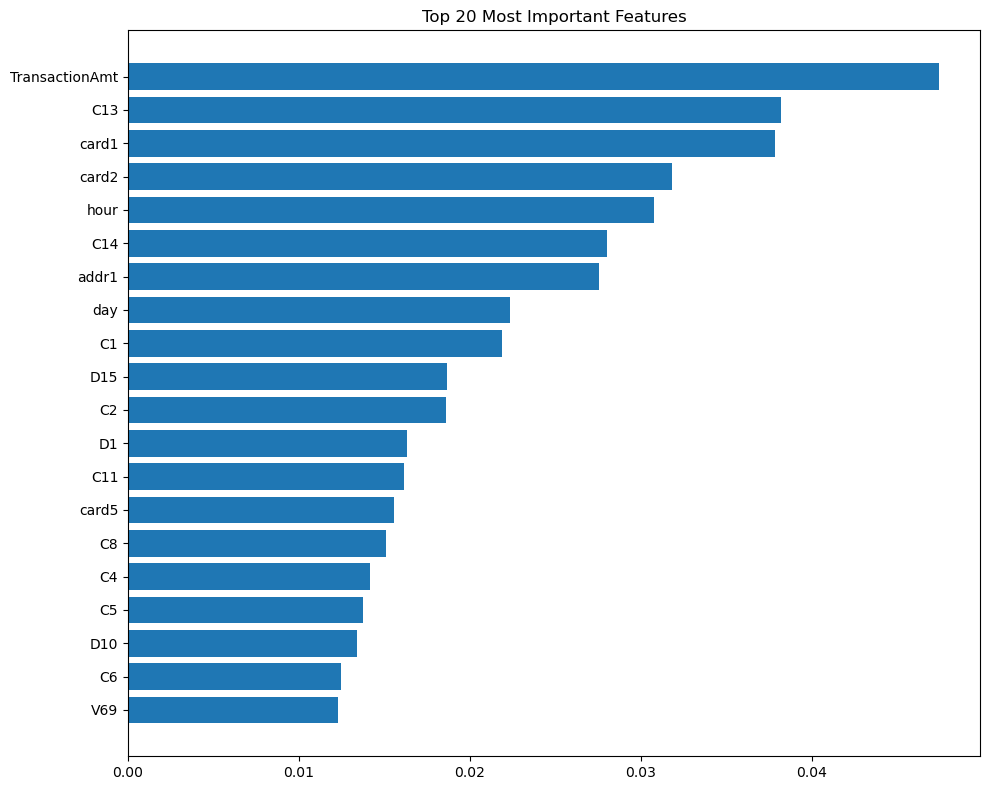

In [99]:
importances = model.feature_importances_
indices = np.argsort(importances)[-20:]  # top 20 features

plt.figure(figsize=(10, 8))
plt.barh(range(20), importances[indices])
plt.yticks(range(20), [X.columns[i] for i in indices])
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.savefig('../models/feature_importance.png')
plt.show()

In [100]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))

              precision    recall  f1-score   support

  Legitimate       0.99      0.92      0.95     96879
       Fraud       0.26      0.82      0.40      3513

    accuracy                           0.91    100392
   macro avg       0.63      0.87      0.67    100392
weighted avg       0.97      0.91      0.93    100392



In [102]:
joblib.dump(model, '../models/XGBoost.pkl')
print("Model saved")

# verify it loads correctly
loaded_model = joblib.load('../models/XGBoost.pkl')
y_pred_verify = loaded_model.predict(X_test[:5])
print(f"Verification predictions: {y_pred_verify}")

Model saved
Verification predictions: [0 1 0 0 0]
